# Notebook 09 — Classifier-Free Guidance on MNIST

**Chapter reference:** ch09 Extensions → Guidance  
**Key paper:** Ho & Salimans 2022, *Classifier-Free Diffusion Guidance*

## Overview

This notebook demonstrates **Classifier-Free Guidance (CFG)** for class-conditional image generation on MNIST.  The core idea is to train a single DDPM that can operate in both conditional and unconditional modes by randomly dropping class labels during training.  At inference, the two modes are combined:

$$
\hat\varepsilon_\theta(x_t, t, c) = \varepsilon_\theta(x_t, t, \varnothing) + w\bigl(\varepsilon_\theta(x_t, t, c) - \varepsilon_\theta(x_t, t, \varnothing)\bigr)
$$

where $w \ge 0$ is the **guidance scale**:
- $w = 0$: unconditional generation (ignores $c$)
- $w = 1$: standard conditional generation
- $w > 1$: amplified guidance (sharper, more class-typical, lower diversity)

## Topics covered
1. Train `CondDDPM` on MNIST (labels 0–9)
2. Guidance scale sweep: visualise samples at $w \in \{0, 1, 2, 4, 7\}$
3. Class-conditional grid ($10 \times 8$ samples per class)
4. FID vs guidance scale (optional — requires large sample count)
5. Verify that $w=0$ recovers unconditional samples
6. DDIM + CFG for fast conditional generation

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from diffusion_lab.data.mnist      import get_mnist_loader, denormalize
from diffusion_lab.schedulers      import cosine_vp_schedule
from diffusion_lab.nn.unet         import SmallUNet
from diffusion_lab.models.guidance import CondDDPM, CFGSampler

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'device: {device}')
torch.manual_seed(0)

device: mps


## 1. Data

Standard MNIST in `[-1, 1]`.  We use the **class labels** (0–9) directly.  The `CondDDPM` training loop will reserve index 0 as the null/unconditional token, so we shift labels by +1 (making them 1–10) and set `num_classes=10`.

In [2]:
# ── Data ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 256
train_loader = get_mnist_loader(split='train', batch_size=BATCH_SIZE,
                                cache_dir='../data/mnist', num_workers=0)
test_loader  = get_mnist_loader(split='test',  batch_size=BATCH_SIZE,
                                cache_dir='../data/mnist', num_workers=0)

print(f'Train batches: {len(train_loader)}')
xb, yb = next(iter(train_loader))
print(f'Image batch shape: {xb.shape}  label range: [{yb.min()}, {yb.max()}]')

Train batches: 234
Image batch shape: torch.Size([256, 1, 28, 28])  label range: [0, 9]


## 2. Build CondDDPM

We wrap `SmallUNet` (built with `num_classes=10`) inside `CondDDPM`.

> **Class-label convention:**  
> - MNIST digit $d \in \{0,\dots,9\}$ is passed to the network as label $c = d + 1 \in \{1,\dots,10\}$.  
> - Index 0 is reserved as the **null/unconditional** token used during CFG dropout.

> **`p_uncond = 0.15`:** 15% of samples in each batch will have their label replaced by 0 (null) during training, following Ho & Salimans 2022.

In [3]:
# ── Model ─────────────────────────────────────────────────────────────────
NUM_CLASSES = 10          # digits 0–9; labels fed to network as 1–10
T           = 1000
P_UNCOND    = 0.15        # fraction of training samples with dropped labels

schedule = cosine_vp_schedule(T=T).to(device)   # must be on same device as model

net = SmallUNet(
    in_channels    = 1,
    out_channels   = 1,
    base_channels  = 32,
    time_embed_dim = 128,
    dropout        = 0.1,
    num_classes    = NUM_CLASSES,
)

model = CondDDPM(
    network     = net,
    schedule    = schedule,
    p_uncond    = P_UNCOND,
    prediction  = 'epsilon',   # valid values: 'epsilon', 'x0', 'v'
    loss_weight = 'uniform',
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'CondDDPM parameters: {n_params:,}')

CondDDPM parameters: 1,591,425


## 3. Training loop

The training loss is identical to DDPM except that:
1. Class labels are passed along with images.
2. Each label is independently dropped to 0 with probability `p_uncond`.

This is the CFG training procedure of Ho & Salimans 2022.

In [4]:
EPOCHS   = 30          # ≥20 for decent quality; increase to 60+ for sharp digits
LR       = 3e-4
CKPT     = pathlib.Path('../checkpoints/cond_ddpm_mnist.pt')
CKPT.parent.mkdir(exist_ok=True)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

loss_history = []

if CKPT.exists():
    model.load_state_dict(torch.load(CKPT, map_location=device))
    print(f'Loaded checkpoint from {CKPT}')
else:
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        for x, y in train_loader:
            x = x.to(device)
            # Shift labels: digit d → class index d+1; null token = 0
            c = (y + 1).to(device)          # {1, …, 10}

            optimizer.zero_grad()
            loss = model.loss(x, c)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        scheduler_lr.step()
        avg = epoch_loss / len(train_loader)
        loss_history.append(avg)
        if epoch % 5 == 0:
            print(f'Epoch {epoch:3d}/{EPOCHS}  loss = {avg:.4f}')

    torch.save(model.state_dict(), CKPT)
    print(f'Checkpoint saved → {CKPT}')

Epoch   5/30  loss = 0.0902
Epoch  10/30  loss = 0.0685
Epoch  15/30  loss = 0.0612
Epoch  20/30  loss = 0.0577
Epoch  25/30  loss = 0.0562
Epoch  30/30  loss = 0.0560
Checkpoint saved → ../checkpoints/cond_ddpm_mnist.pt


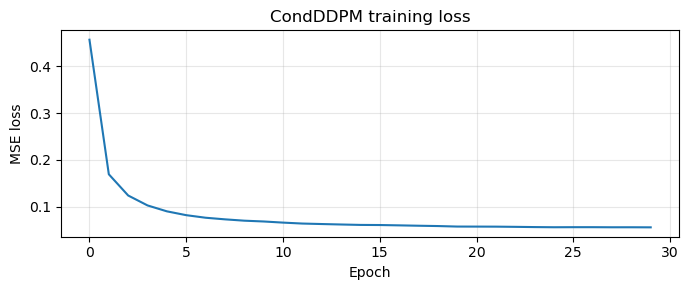

In [5]:
# ── Training curve ────────────────────────────────────────────────────────
if loss_history:
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(loss_history, lw=1.5)
    ax.set(xlabel='Epoch', ylabel='MSE loss', title='CondDDPM training loss')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

## 4. Guidance scale sweep

We fix the target class (digit 3) and sample 8 images at each guidance scale $w \in \{0, 1, 2, 4, 7\}$.  The CFG formula applies the guided score:

$$
\hat\varepsilon = \varepsilon_\theta(x_t, t, \varnothing) + w\bigl(\varepsilon_\theta(x_t, t, c) - \varepsilon_\theta(x_t, t, \varnothing)\bigr)
$$

- $w=0$: unconditional (no label knowledge)
- $w=1$: standard conditional
- $w>1$: the guidance signal is **amplified** — samples become more prototypical of the class but at the cost of diversity and, at very high $w$, artifacts.

In [6]:
GUIDANCE_SCALES = [0.0, 1.0, 2.0, 4.0, 7.0]
N_SAMPLES       = 8
TARGET_DIGIT    = 3     # will be passed as label 4 (= digit + 1)
TARGET_LABEL    = TARGET_DIGIT + 1
DDIM_STEPS      = 50

all_grids = {}   # w → (N, 1, 28, 28) tensor

for w in GUIDANCE_SCALES:
    sampler = CFGSampler(model, guidance_scale=w)
    labels  = torch.full((N_SAMPLES,), TARGET_LABEL, dtype=torch.long)
    shape   = (N_SAMPLES, 1, 28, 28)

    # Use fast DDIM for the sweep
    with torch.no_grad():
        samples = sampler.sample_ddim(
            shape, labels, device=device,
            num_steps=DDIM_STEPS, eta=0.0
        )
    all_grids[w] = samples.clamp(-1, 1).cpu()
    print(f'  w={w:.1f}  done')

print('Sampling complete.')

  w=0.0  done
  w=1.0  done
  w=2.0  done
  w=4.0  done
  w=7.0  done
Sampling complete.


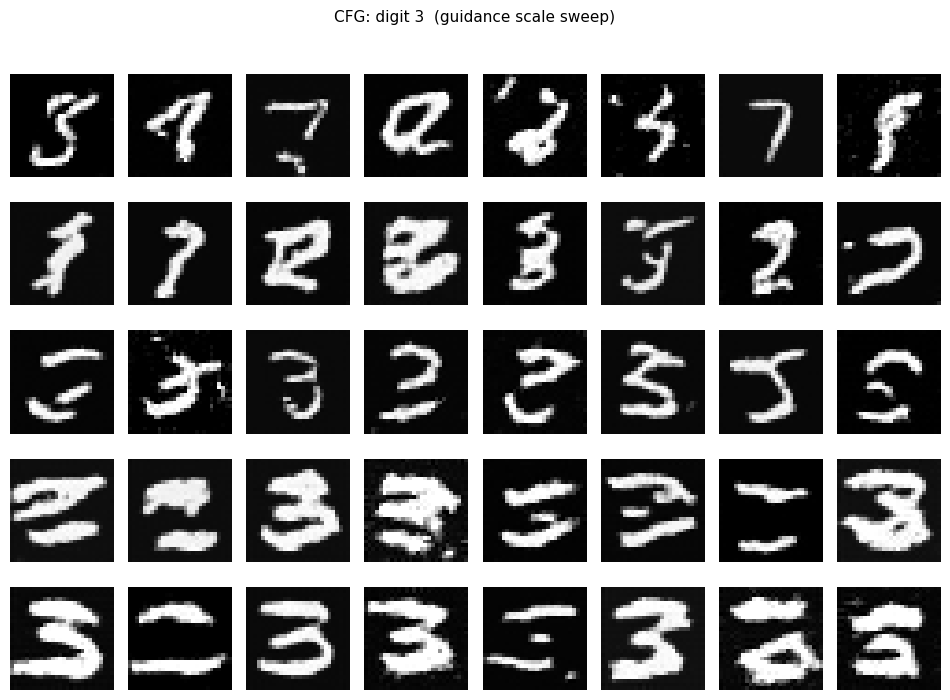

In [7]:
# ── Visualise guidance scale sweep ────────────────────────────────────────
def show_row(imgs, ax_row, title=''):
    """imgs: (N, 1, 28, 28) in [-1, 1]"""
    for j, img in enumerate(imgs):
        ax_row[j].imshow(img[0].numpy() * 0.5 + 0.5, cmap='gray',
                         vmin=0, vmax=1, interpolation='nearest')
        ax_row[j].axis('off')
    ax_row[0].set_ylabel(title, fontsize=9, rotation=0,
                         labelpad=55, va='center')

fig, axes = plt.subplots(
    len(GUIDANCE_SCALES), N_SAMPLES,
    figsize=(N_SAMPLES * 1.2, len(GUIDANCE_SCALES) * 1.4),
)

for row, w in enumerate(GUIDANCE_SCALES):
    show_row(all_grids[w], axes[row], title=f'w = {w}')

fig.suptitle(f'CFG: digit {TARGET_DIGIT}  (guidance scale sweep)', fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

**Expected observation:**
- $w=0$ produces mixed / unconditioned samples (different digits or blurry)
- $w=1$ produces plausible digit 3s with natural variation
- $w>1$ produces sharper, more stereotypical 3s but with less diversity
- Very large $w$ can introduce brightness artefacts or hypersharpening

## 5. Full class grid

Sample 8 images for each digit 0–9 at guidance scale $w=3$.

In [10]:
W_CLASS_GRID = 7.0
N_PER_CLASS  = 8
TOTAL        = 10 * N_PER_CLASS

sampler = CFGSampler(model, guidance_scale=W_CLASS_GRID)

# Labels: repeat [1,2,...,10] N_PER_CLASS times, interleaved
labels_grid = torch.tensor(
    [d + 1 for d in range(10) for _ in range(N_PER_CLASS)], dtype=torch.long
)

with torch.no_grad():
    class_grid_samples = sampler.sample_ddim(
        (TOTAL, 1, 28, 28), labels_grid, device=device,
        num_steps=DDIM_STEPS, eta=0.0
    )

class_grid_samples = class_grid_samples.clamp(-1, 1).cpu()
print(f'Generated {TOTAL} class-conditional samples.  Shape: {class_grid_samples.shape}')

Generated 80 class-conditional samples.  Shape: torch.Size([80, 1, 28, 28])


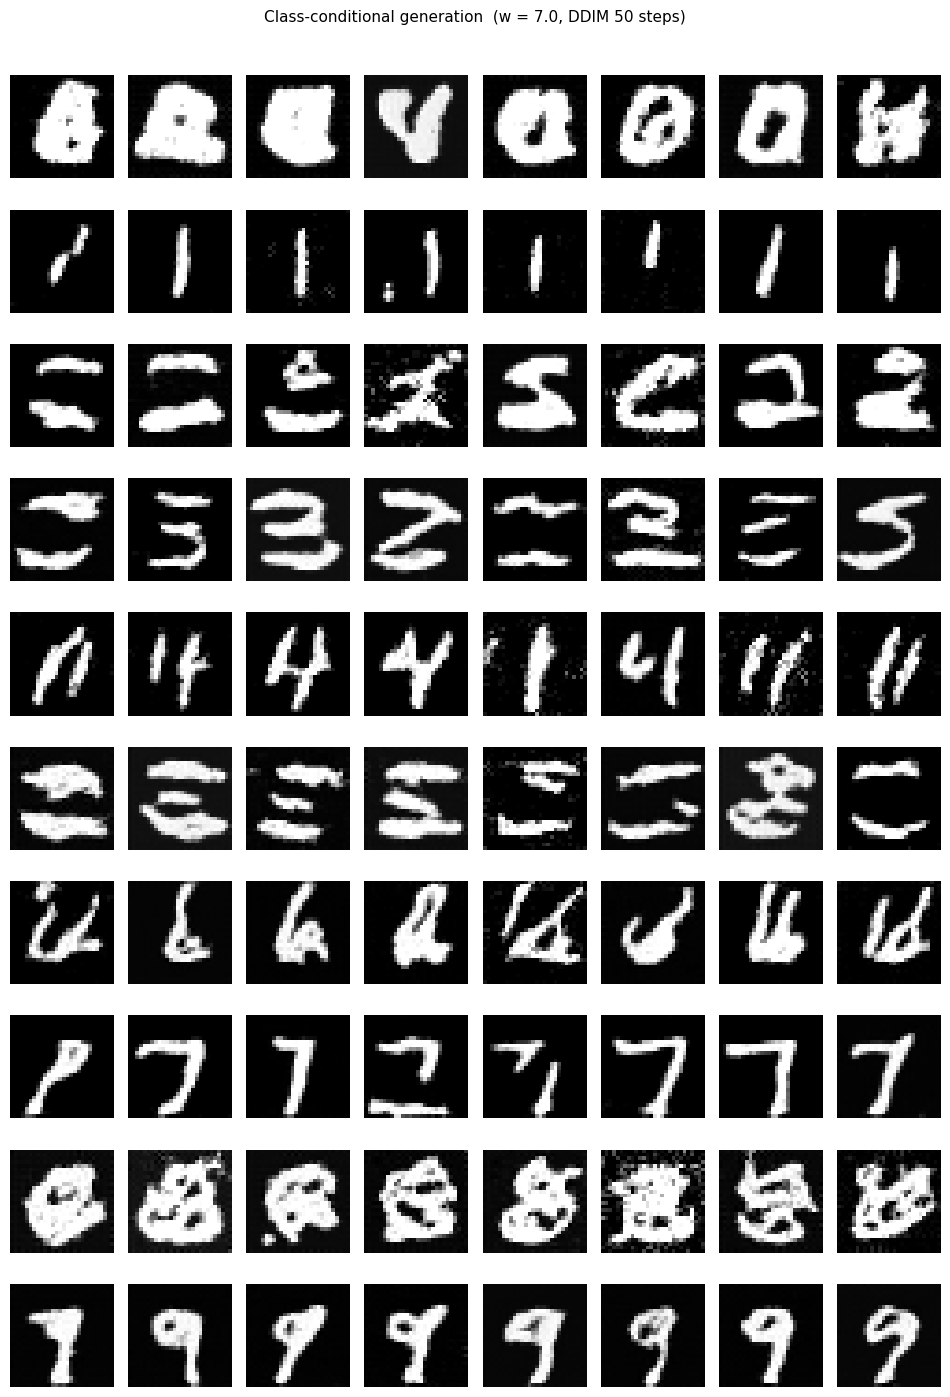

In [11]:
# ── Class grid visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(10, N_PER_CLASS,
                          figsize=(N_PER_CLASS * 1.2, 10 * 1.4))

for d in range(10):
    imgs = class_grid_samples[d * N_PER_CLASS:(d + 1) * N_PER_CLASS]
    for j in range(N_PER_CLASS):
        axes[d, j].imshow(imgs[j, 0].numpy() * 0.5 + 0.5,
                          cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        axes[d, j].axis('off')
    axes[d, 0].set_ylabel(str(d), fontsize=11, rotation=0,
                           labelpad=20, va='center')

fig.suptitle(f'Class-conditional generation  (w = {W_CLASS_GRID}, DDIM {DDIM_STEPS} steps)',
             fontsize=11, y=1.005)
fig.tight_layout()
plt.show()

## 6. Unconditional vs conditional comparison

The same trained model can produce unconditional samples by passing $w=0$ (or all-null labels).  This is CFG's key advantage over classifier guidance: **one model handles both regimes**.

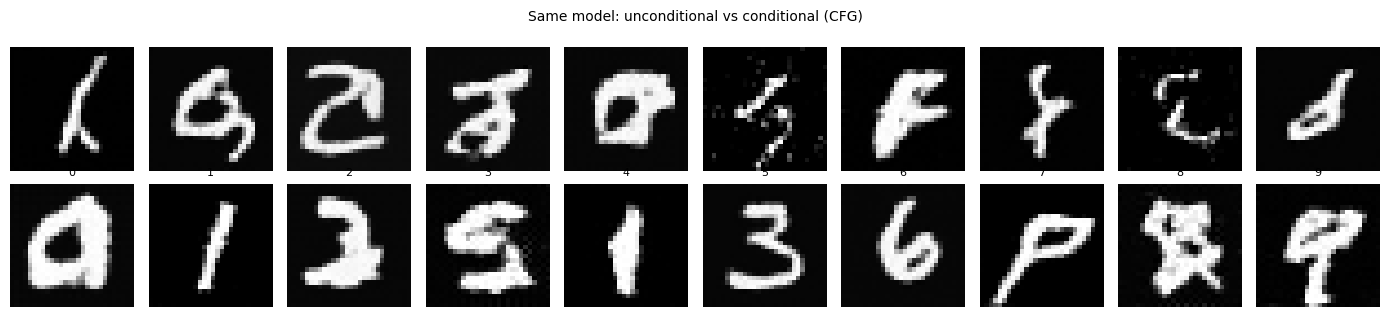

In [12]:
N_COMPARE = 10

sampler_uncond = CFGSampler(model, guidance_scale=0.0)
sampler_cond   = CFGSampler(model, guidance_scale=3.0)

# Choose one label per sample: digits 0–9
compare_labels = torch.arange(1, N_COMPARE + 1, dtype=torch.long)
shape_c        = (N_COMPARE, 1, 28, 28)

with torch.no_grad():
    uncond_samples = sampler_uncond.sample_ddim(
        shape_c, compare_labels, device=device, num_steps=50, eta=0.0)
    cond_samples   = sampler_cond.sample_ddim(
        shape_c, compare_labels, device=device, num_steps=50, eta=0.0)

uncond_samples = uncond_samples.clamp(-1, 1).cpu()
cond_samples   = cond_samples.clamp(-1, 1).cpu()

fig, axes = plt.subplots(2, N_COMPARE, figsize=(N_COMPARE * 1.4, 3.2))
row_titles = ['Unconditional (w=0)', 'Conditional (w=3)']
for row, (row_title, samples) in enumerate(zip(row_titles,
                                               [uncond_samples, cond_samples])):
    for j in range(N_COMPARE):
        axes[row, j].imshow(samples[j, 0].numpy() * 0.5 + 0.5,
                             cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        axes[row, j].axis('off')
        if row == 1:
            axes[row, j].set_title(str(j), fontsize=8)
    axes[row, 0].set_ylabel(row_title, fontsize=8, rotation=0,
                             labelpad=100, va='center')

fig.suptitle('Same model: unconditional vs conditional (CFG)', fontsize=10)
fig.tight_layout()
plt.show()

## 7. Guidance scale effect on class accuracy

We measure how often samples of each class actually *look* like the intended digit by fitting a simple linear classifier on real MNIST and running it on generated samples across guidance scales.  This gives an empirical **IS-like** quality curve.

> **Note:** a proper FID sweep requires 10K+ samples.  The cell below uses 100 samples per class for a fast diagnostic.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ── Train a simple linear classifier on real MNIST flattened pixels ───────
X_real, y_real = [], []
for x, y in train_loader:
    X_real.append(x.view(x.size(0), -1).numpy())
    y_real.append(y.numpy())
    if len(X_real) * BATCH_SIZE >= 10000:
        break

X_real = np.concatenate(X_real)[:10000]
y_real = np.concatenate(y_real)[:10000]

scaler = StandardScaler().fit(X_real)
clf    = LogisticRegression(max_iter=300, C=1.0)
clf.fit(scaler.transform(X_real), y_real)
print(f'Classifier train acc: {clf.score(scaler.transform(X_real), y_real):.3f}')

Classifier train acc: 0.998


  w=0.0  class acc = 0.088
  w=0.5  class acc = 0.170
  w=1.0  class acc = 0.210
  w=1.5  class acc = 0.284
  w=2.0  class acc = 0.344
  w=3.0  class acc = 0.434
  w=4.0  class acc = 0.468
  w=5.0  class acc = 0.482
  w=7.0  class acc = 0.492


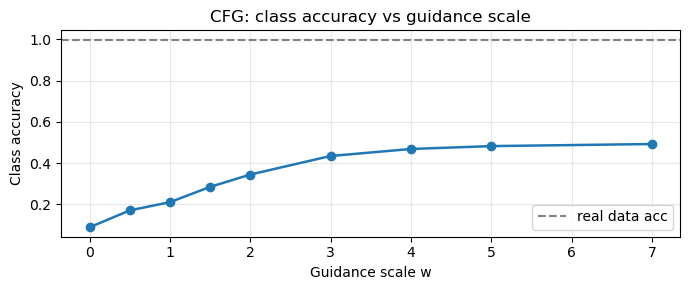

In [14]:
# ── Class accuracy across guidance scales ─────────────────────────────────
N_EVAL = 50    # samples per class — increase for more reliable estimates
w_values = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.0]
accs = []

for w in w_values:
    samp = CFGSampler(model, guidance_scale=w)
    lbls = torch.tensor([d + 1 for d in range(10)
                          for _ in range(N_EVAL)], dtype=torch.long)
    true_digits = torch.tensor([d for d in range(10)
                                  for _ in range(N_EVAL)]).numpy()

    with torch.no_grad():
        imgs = samp.sample_ddim(
            (10 * N_EVAL, 1, 28, 28), lbls,
            device=device, num_steps=30, eta=0.0
        ).clamp(-1, 1)

    X_gen = imgs.cpu().view(imgs.size(0), -1).numpy()
    preds = clf.predict(scaler.transform(X_gen))
    acc   = (preds == true_digits).mean()
    accs.append(acc)
    print(f'  w={w:.1f}  class acc = {acc:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(w_values, accs, 'o-', lw=1.8)
ax.axhline(clf.score(scaler.transform(X_real), y_real), ls='--',
           color='grey', label='real data acc')
ax.set(xlabel='Guidance scale w', ylabel='Class accuracy',
       title='CFG: class accuracy vs guidance scale')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 8. DDIM + CFG: NFE sweep

Combine CFG with DDIM sub-sampling to achieve high-quality conditional generation in few network function evaluations (NFE).  Each Heun step calls the network **twice** (conditional and unconditional in one batched forward pass), so the effective NFE is $2S$ for $S$ DDIM steps.

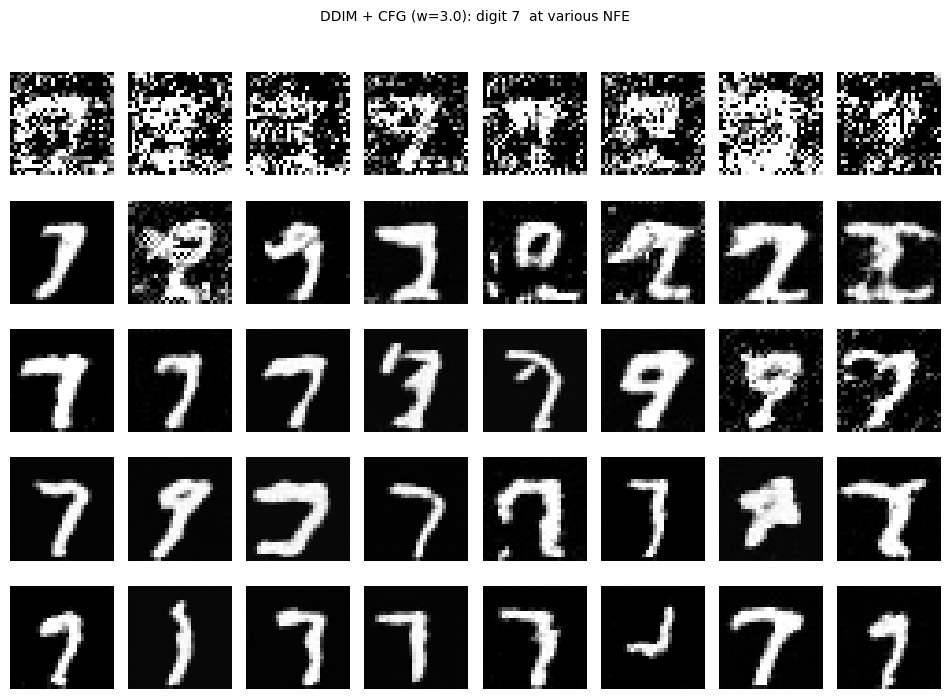

In [15]:
W_FIXED    = 3.0
NFE_STEPS  = [5, 10, 20, 50, 100]
N_ROW      = 8
DIGIT_SHOW = 7

sampler_nfe = CFGSampler(model, guidance_scale=W_FIXED)
labels_nfe  = torch.full((N_ROW,), DIGIT_SHOW + 1, dtype=torch.long)

nfe_samples = {}
for steps in NFE_STEPS:
    with torch.no_grad():
        s = sampler_nfe.sample_ddim(
            (N_ROW, 1, 28, 28), labels_nfe,
            device=device, num_steps=steps, eta=0.0
        ).clamp(-1, 1).cpu()
    nfe_samples[steps] = s

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(NFE_STEPS), N_ROW,
                          figsize=(N_ROW * 1.2, len(NFE_STEPS) * 1.4))
for row, steps in enumerate(NFE_STEPS):
    for j in range(N_ROW):
        axes[row, j].imshow(nfe_samples[steps][j, 0].numpy() * 0.5 + 0.5,
                             cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        axes[row, j].axis('off')
    axes[row, 0].set_ylabel(f'S={steps}\n(NFE={2*steps})',
                             fontsize=8, rotation=0, labelpad=60, va='center')

fig.suptitle(f'DDIM + CFG (w={W_FIXED}): digit {DIGIT_SHOW}  at various NFE',
             fontsize=10, y=1.01)
fig.tight_layout()
plt.show()

## 9. Summary

| Concept | Implementation note |
|---------|--------------------|
| CFG training | `CondDDPM.loss(x0, labels)` — drops labels to 0 with prob `p_uncond` |
| CFG inference | `CondDDPM._net_cfg` — batched 2B forward, computes $\hat\varepsilon_{\text{guided}}$ |
| Null token | Class index 0 in `SmallUNet.class_embed` |
| Guidance scale $w$ | `CFGSampler(model, guidance_scale=w)` |
| Fast sampling | `CFGSampler.sample_ddim(…, num_steps=50, eta=0)` |

**Key takeaway:** CFG amplifies the difference between the conditional and unconditional score fields.  The guidance scale $w$ directly trades **diversity** for **adherence to the conditioning signal**.  The optimal $w$ is problem-dependent and must be tuned empirically — typical values for MNIST are 2–5, while text-to-image models often use 7–15.